In [2]:
using Clapeyron, Metaheuristics, Printf

In [3]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
propanoicacid,74.08,3.01515,3.205896845,200.6790442,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,propanoicacid,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanoicacid,H,propanoicacid,e,2556.969996,0.052555
co2,H,co2,e,0,0
propanoicacid,H,co2,e,1278.485,0
propanoicacid,e,co2,H,1278.485,0
"""

model = PCSAFT(["co2", "propanoicacid"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 186.3805163454726; 186.3805163454726 200.6790442]
[2.785e-10 2.9954484225e-10; 2.9954484225e-10 3.205896845e-10]
kij = -0.010000000000000009


In [4]:
function vle(model::EoSModel, x_co2::Float64)
    T = 298.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

vle (generic function with 1 method)

In [5]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 100.0,
        :upper   => 200.0,
        :guess   => 150.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 200.0, :param => :epsilon, :indices => (1, 2), :guess => 150.0, :lower => 100.0)

In [6]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vle_propanoicacid.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vle_propanoicacid.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vle_propanoicacid.csv
Initial objective value: 0.8644447460937759


In [7]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([169.71893686011407], PCSAFT{BasicIdeal, Float64}("co2", "propanoicacid"))

In [8]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 169.71893686011407; 169.71893686011407 200.6790442]
[2.785e-10 2.9954484225e-10; 2.9954484225e-10 3.205896845e-10]
kij = 0.0802894551972353


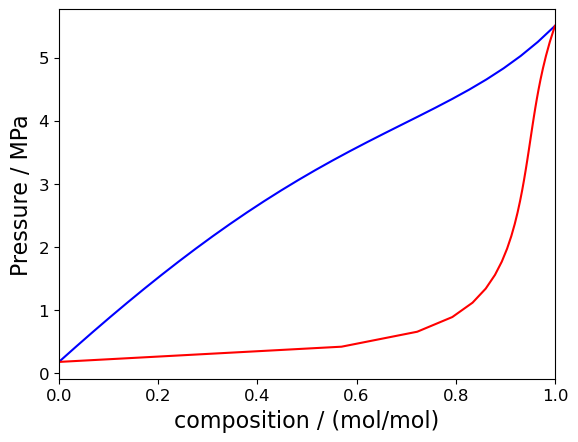

([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0], PyCall.PyObject[PyObject Text(0, -1.0, '−1'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 1.0, '1'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 3.0, '3'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 5.0, '5'), PyObject Text(0, 6.0, '6')])

In [9]:
import PyPlot; const plt = PyPlot

N    = 30
T    = 293.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [10]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [11]:
aard_p   = calculate_AAD(model_opt, "vle_propanoicacid.csv", vle)


=== AAD: vle_propanoicacid.csv ===


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


Clapeyron Estimator  exp           calc          ARD%    
0.1292      1009000.000000  1154386.204326  14.4089 
0.2505      1993000.000000  1979087.679898  0.6981  
0.3853      2995000.000000  2806096.365246  6.3073  
0.5291      3996000.000000  3573730.450060  10.5673 
0.7103      4995000.000000  4411271.126124  11.6863 
0.8224      5506000.000000  4938728.714640  10.3028 
0.9406      5997000.000000  5653263.801711  5.7318  
AARD = 8.5289%


8.528922211673413